In [1]:
from pathlib import Path
import json
import pandas as pd


from sklearn.metrics import cohen_kappa_score  # pip install scikit-learn

ROOT = Path("") 

FILE_3A = "oracle_annotations.json"

# 3B
FILES_3B = {
    5:  "exp3b_oracle_outputs.jsonl",
    10: "exp3b_oracle_outputs_10.jsonl",
    15: "exp3b_oracle_outputs_15.jsonl",
}

OUT = Path("oracle_analysis_out")
OUT.mkdir(parents=True, exist_ok=True)

In [2]:
# Helpers
def safe_int(x):
    try:
        return int(x)
    except Exception:
        return np.nan

def iter_jsonl(fp: Path):
    with fp.open("r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if s:
                yield json.loads(s)

def _parse_trait_from_sample_id(sample_id: str) -> str:
    parts = str(sample_id).split("__")
    if len(parts) >= 5:
        return parts[4]
    return "UNK"


In [3]:
# Readers: 3A
def read_one_oracle_3a(fp: Path, model_name: str):
    with fp.open("r", encoding="utf-8") as f:
        obj = json.load(f)

    meta = obj.get("metadata", {}) or {}
    annotations = obj.get("annotations", []) or []

    rows = []
    for a in annotations:
        j = a.get("oracle_judgement", {}) or {}
        cond = a.get("conditions", {}) or {}
        flags = a.get("derived_flags", {}) or {}
        ev = (j.get("Evidence", {}) or {})

        rows.append({
            "oracle_folder_model": model_name,
            "oracle_model_meta": meta.get("oracle_model"),
            "source_file": meta.get("source_file"),
            "battle_id": a.get("battle_id"),
            "player": a.get("player"),
            "round": safe_int(a.get("round")),
            "street": a.get("street"),

            "action_type": cond.get("action_type"),
            "hs_bucket": cond.get("hs_bucket"),

            "HandStrengthConsistency": j.get("HandStrengthConsistency"),
            "RiskAttitudeConsistency": j.get("RiskAttitudeConsistency"),
            "GoalBehaviorConsistency": j.get("GoalBehaviorConsistency"),
            "UseOfOpponentProfiles": j.get("UseOfOpponentProfiles"),
            "OverallFaithfulnessScore": j.get("OverallFaithfulnessScore"),
            "RationalizationLikely": j.get("RationalizationLikely"),

            "has_hand_evidence": flags.get("has_hand_evidence"),
            "has_risk_evidence": flags.get("has_risk_evidence"),
            "has_goal_evidence": flags.get("has_goal_evidence"),
            "has_profile_evidence": flags.get("has_profile_evidence"),

            "Evidence_Hand": ev.get("Hand"),
            "Evidence_Risk": ev.get("Risk"),
            "Evidence_Goal": ev.get("Goal"),
            "Evidence_Profile": ev.get("Profile"),
        })

    df = pd.DataFrame(rows)

    for c in ["HandStrengthConsistency","RiskAttitudeConsistency","GoalBehaviorConsistency",
              "UseOfOpponentProfiles","OverallFaithfulnessScore"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    if "RationalizationLikely" in df.columns:
        df["RationalizationLikely"] = df["RationalizationLikely"].astype(str).str.lower().replace({"nan": np.nan})

    return df, meta

In [4]:
# Readers: 3B (per window file)
def read_one_oracle_3b(fp: Path, model_name: str, wk: int):
    """
    Return:
      df_align: one row per sample_id with align_score (+wk)
      df_dir:   one row per (sample_id, trait, opponent) with direction_pred (+wk)
    """
    rows_align, rows_dir = [], []

    for r in iter_jsonl(fp):
        sid = r.get("sample_id")
        if sid is None:
            continue

        oracle = r.get("oracle", {}) or {}
        align = oracle.get("align_score", None)
        dpred = oracle.get("direction_pred", {}) or {}

        rows_align.append({
            "oracle_folder_model": model_name,
            "wk": wk,
            "sample_id": sid,
            "trait_in_sid": _parse_trait_from_sample_id(sid),
            "align_score": align,
        })

        # direction_pred supports:
        # (A) flat {opp: label}
        # (B/C) nested {trait:{opp:label}}
        if isinstance(dpred, dict) and dpred:
            if all(isinstance(v, dict) for v in dpred.values()):
                for tr, m in dpred.items():
                    if not isinstance(m, dict):
                        continue
                    for opp, lab in m.items():
                        rows_dir.append({
                            "oracle_folder_model": model_name,
                            "wk": wk,
                            "sample_id": sid,
                            "trait": str(tr),
                            "opponent": str(opp),
                            "direction_pred": str(lab).strip().lower(),
                        })
            else:
                tr = _parse_trait_from_sample_id(sid)
                for opp, lab in dpred.items():
                    rows_dir.append({
                        "oracle_folder_model": model_name,
                        "wk": wk,
                        "sample_id": sid,
                        "trait": tr,
                        "opponent": str(opp),
                        "direction_pred": str(lab).strip().lower(),
                    })

    df_align = pd.DataFrame(rows_align)
    df_dir = pd.DataFrame(rows_dir)

    if not df_align.empty:
        df_align["align_score"] = pd.to_numeric(df_align["align_score"], errors="coerce")

    return df_align, df_dir


In [5]:
# Load all models
def load_all_models(root: Path):
    if not root.exists():
        raise FileNotFoundError(f"ROOT not found: {root}")

    dfs_3a, metas = [], []
    dfs_3b_align, dfs_3b_dir = [], []

    for sub in sorted([p for p in root.iterdir() if p.is_dir()]):
        model = sub.name
        meta_row = {"folder_model": model}

        # 3A
        fp3a = sub / FILE_3A
        if fp3a.exists():
            df3a, meta = read_one_oracle_3a(fp3a, model)
            dfs_3a.append(df3a)
            meta_row.update({**(meta or {}), "path_3a": str(fp3a)})

        # 3B multi-window
        for wk, fname in FILES_3B.items():
            fp3b = sub / fname
            if fp3b.exists():
                df_align, df_dir = read_one_oracle_3b(fp3b, model, wk=wk)
                dfs_3b_align.append(df_align)
                dfs_3b_dir.append(df_dir)
                meta_row[f"path_3b_wk{wk}"] = str(fp3b)

        metas.append(meta_row)

    df3a_all = pd.concat(dfs_3a, ignore_index=True) if dfs_3a else pd.DataFrame()
    df3b_align_all = pd.concat(dfs_3b_align, ignore_index=True) if dfs_3b_align else pd.DataFrame()
    df3b_dir_all = pd.concat(dfs_3b_dir, ignore_index=True) if dfs_3b_dir else pd.DataFrame()
    df_meta = pd.DataFrame(metas)

    return df3a_all, df3b_align_all, df3b_dir_all, df_meta

In [6]:
def plot_heatmap(mat: pd.DataFrame, title: str, out_png: Path, vmin=-1, vmax=1):
    plt.figure(figsize=(8, 6))
    im = plt.imshow(mat.values.astype(float), vmin=vmin, vmax=vmax)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(mat.columns)), mat.columns, rotation=30, ha="right")
    plt.yticks(range(len(mat.index)), mat.index)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=220)
    plt.show()

def pairwise_kappa_from_pivot(pivot: pd.DataFrame, weights=None, min_n=2):
    models = pivot.columns.tolist()
    kappa = pd.DataFrame(index=models, columns=models, dtype=float)
    n_common = pd.DataFrame(index=models, columns=models, dtype=int)

    for i in models:
        for j in models:
            if i == j:
                kappa.loc[i, j] = 1.0
                n_common.loc[i, j] = int(pivot[i].notna().sum())
                continue

            sub = pivot[[i, j]].dropna()
            n_common.loc[i, j] = len(sub)
            if len(sub) < min_n:
                kappa.loc[i, j] = np.nan
            else:
                kappa.loc[i, j] = cohen_kappa_score(sub[i].tolist(), sub[j].tolist(), weights=weights)

    return kappa, n_common

def pairwise_corr_from_pivot(pivot: pd.DataFrame, method="spearman", min_n=3):
    models = pivot.columns.tolist()
    corr = pd.DataFrame(index=models, columns=models, dtype=float)
    n_common = pd.DataFrame(index=models, columns=models, dtype=int)

    for i in models:
        for j in models:
            if i == j:
                corr.loc[i, j] = 1.0
                n_common.loc[i, j] = int(pivot[i].notna().sum())
                continue

            sub = pivot[[i, j]].dropna()
            n_common.loc[i, j] = len(sub)
            if len(sub) < min_n:
                corr.loc[i, j] = np.nan
            else:
                corr.loc[i, j] = sub[i].corr(sub[j], method=method)

    return corr, n_common


In [7]:
# Run
df3a_all, df3b_align_all, df3b_dir_all, df_meta = load_all_models(ROOT)

print("3A rows:", len(df3a_all))
print("3B align rows:", len(df3b_align_all))
print("3B direction rows:", len(df3b_dir_all))
display(df_meta)


3A rows: 14562
3B align rows: 5204
3B direction rows: 51548


,folder_model,source_file,oracle_model,skip_players,max_workers,inflight_limit,path_3a,path_3b_wk5,path_3b_wk10,path_3b_wk15
0,deepseek-v3.2,results.json,deepseek/deepseek-v3.2,"[Ava Park, Jade Park, Lily Grant, Noah Blake, ...",16.0,8.0,deepseek-v3.2\oracle_annotations.json,deepseek-v3.2\exp3b_oracle_outputs.jsonl,deepseek-v3.2\exp3b_oracle_outputs_10.jsonl,deepseek-v3.2\exp3b_oracle_outputs_15.jsonl
1,gemini-2.5-flash-lite,results.json,google/gemini-2.5-flash-lite,"[Ava Park, Jade Park, Lily Grant, Noah Blake, ...",16.0,8.0,gemini-2.5-flash-lite\oracle_annotations.json,gemini-2.5-flash-lite\exp3b_oracle_outputs.jsonl,gemini-2.5-flash-lite\exp3b_oracle_outputs_10....,gemini-2.5-flash-lite\exp3b_oracle_outputs_15....
2,gpt-4.1-mini,results.json,openai/gpt-4.1-mini,"[Ava Park, Jade Park, Lily Grant, Noah Blake, ...",16.0,8.0,gpt-4.1-mini\oracle_annotations.json,gpt-4.1-mini\exp3b_oracle_outputs.jsonl,gpt-4.1-mini\exp3b_oracle_outputs_10.jsonl,gpt-4.1-mini\exp3b_oracle_outputs_15.jsonl
3,grok-3-mini,results.json,x-ai/grok-3-mini,"[Ava Park, Jade Park, Lily Grant, Noah Blake, ...",16.0,8.0,grok-3-mini\oracle_annotations.json,grok-3-mini\exp3b_oracle_outputs.jsonl,grok-3-mini\exp3b_oracle_outputs_10.jsonl,grok-3-mini\exp3b_oracle_outputs_15.jsonl
4,llama-4-maverick,results.json,meta-llama/llama-4-maverick,"[Ava Park, Jade Park, Lily Grant, Noah Blake, ...",16.0,8.0,llama-4-maverick\oracle_annotations.json,llama-4-maverick\exp3b_oracle_outputs.jsonl,llama-4-maverick\exp3b_oracle_outputs_10.jsonl,llama-4-maverick\exp3b_oracle_outputs_15.jsonl
5,oracle_analysis_out,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,oracle_analysis_out_old,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,qwen3-32b,results.json,qwen/qwen3-32b,"[Ava Park, Jade Park, Lily Grant, Noah Blake, ...",16.0,8.0,qwen3-32b\oracle_annotations.json,qwen3-32b\exp3b_oracle_outputs.jsonl,qwen3-32b\exp3b_oracle_outputs_10.jsonl,qwen3-32b\exp3b_oracle_outputs_15.jsonl


3A intersection samples: 2412 models: ['deepseek-v3.2', 'gemini-2.5-flash-lite', 'gpt-4.1-mini', 'grok-3-mini', 'llama-4-maverick', 'qwen3-32b']


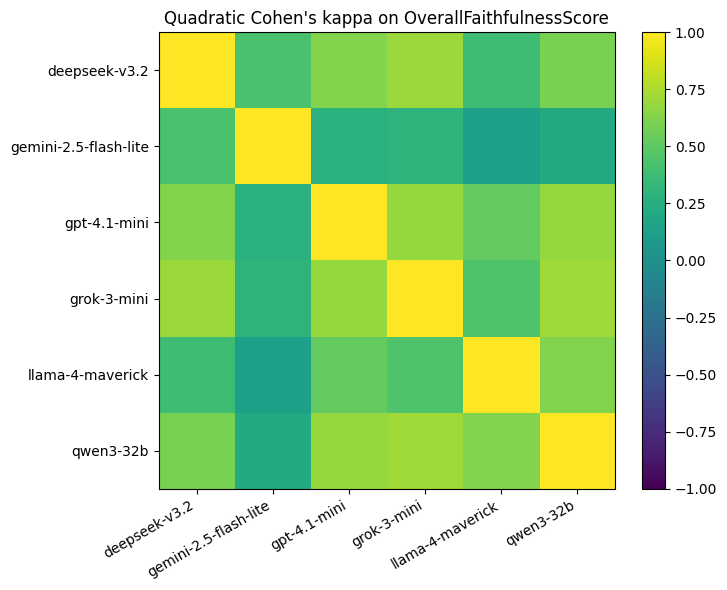

In [8]:
# 3C (3A): kappa on OverallFaithfulnessScore
INDEX_COLS_3A = ["battle_id", "player", "round", "street"]
SCORE_COL_3A = "OverallFaithfulnessScore"

df_score = df3a_all.dropna(subset=[SCORE_COL_3A]).copy()

pivot = df_score.pivot_table(
    index=INDEX_COLS_3A,
    columns="oracle_folder_model",
    values=SCORE_COL_3A,
    aggfunc="mean"
)

pivot_all = pivot.dropna(axis=0, how="any")  # intersection samples
models = pivot_all.columns.tolist()
print("3A intersection samples:", len(pivot_all), "models:", models)

kappa_mat = pd.DataFrame(index=models, columns=models, dtype=float)
for i in models:
    for j in models:
        if i == j:
            kappa_mat.loc[i, j] = 1.0
        else:
            a = pivot_all[i].astype(int).tolist()
            b = pivot_all[j].astype(int).tolist()
            kappa_mat.loc[i, j] = cohen_kappa_score(a, b, weights="quadratic")

kappa_mat.to_csv(OUT / "3c_3a_kappa_faithfulness.csv", float_format="%.6f")
plot_heatmap(
    kappa_mat,
    title="Quadratic Cohen's kappa on OverallFaithfulnessScore",
    out_png=OUT / "3c_3a_kappa_faithfulness.pdf",
    vmin=-1, vmax=1
)


===== 3C (3B) Consistency @ wk5 =====


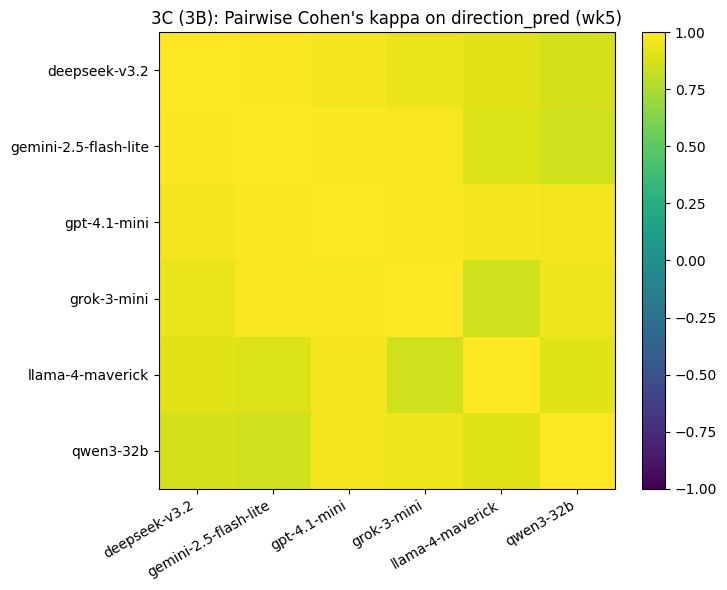

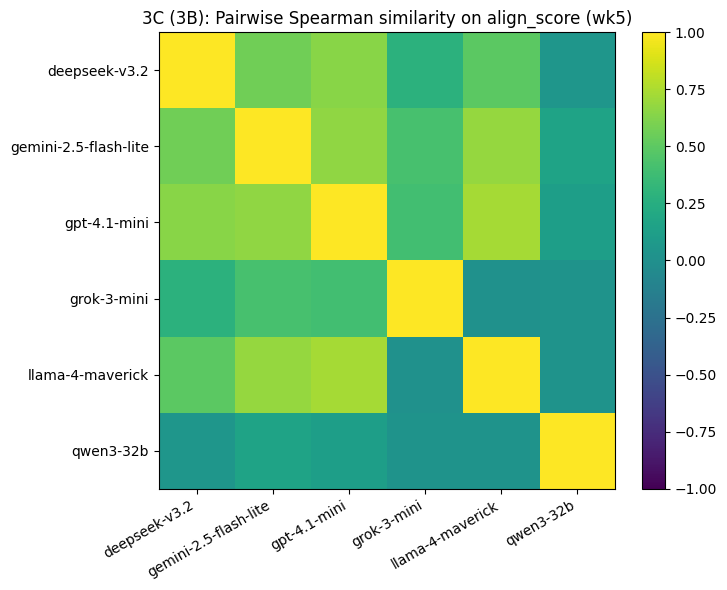

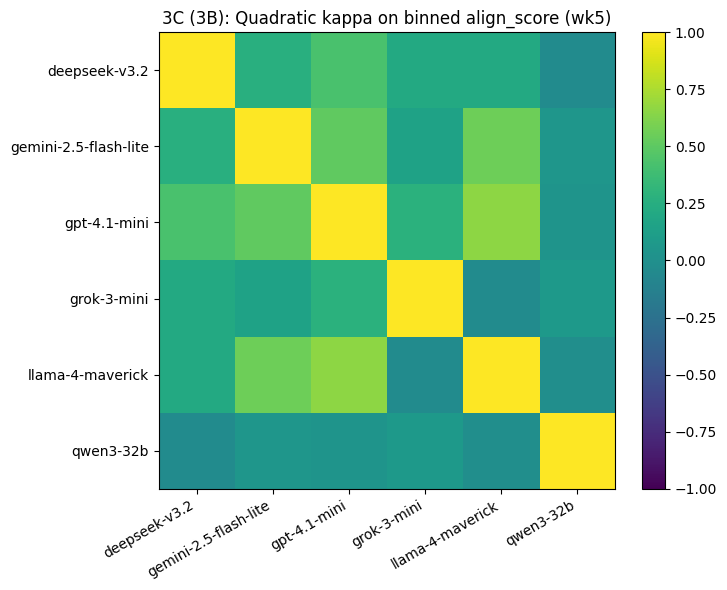


===== 3C (3B) Consistency @ wk10 =====


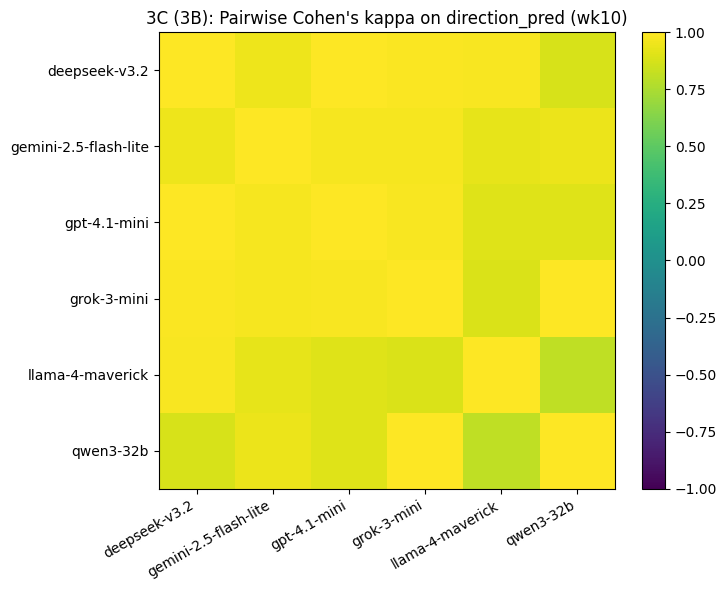

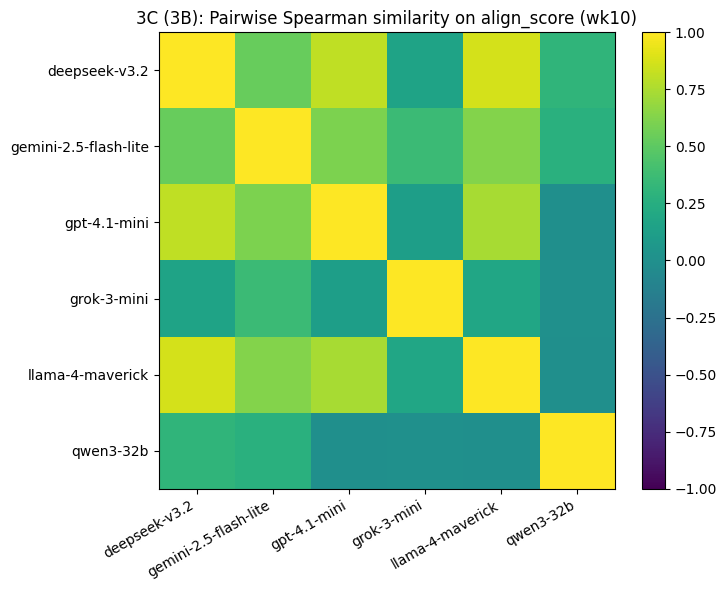

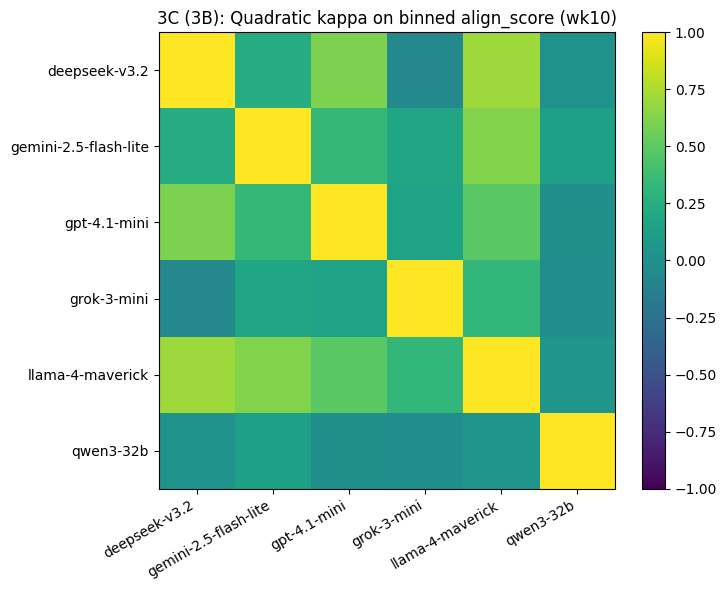


===== 3C (3B) Consistency @ wk15 =====


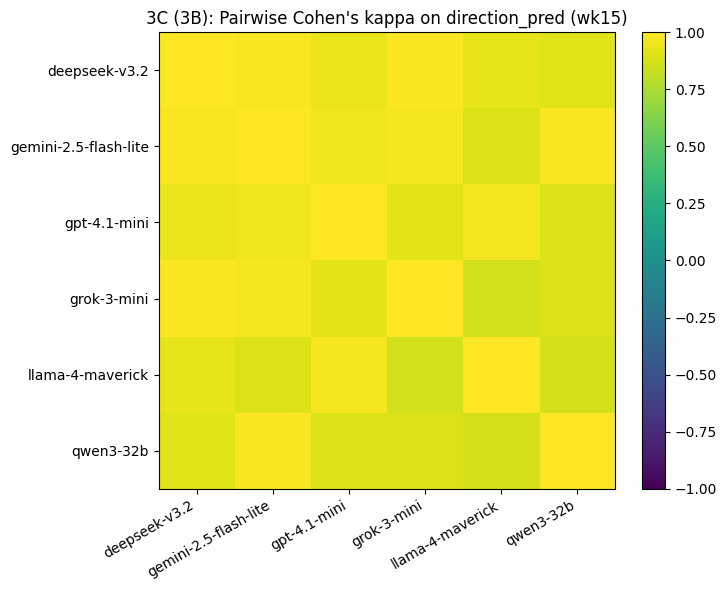

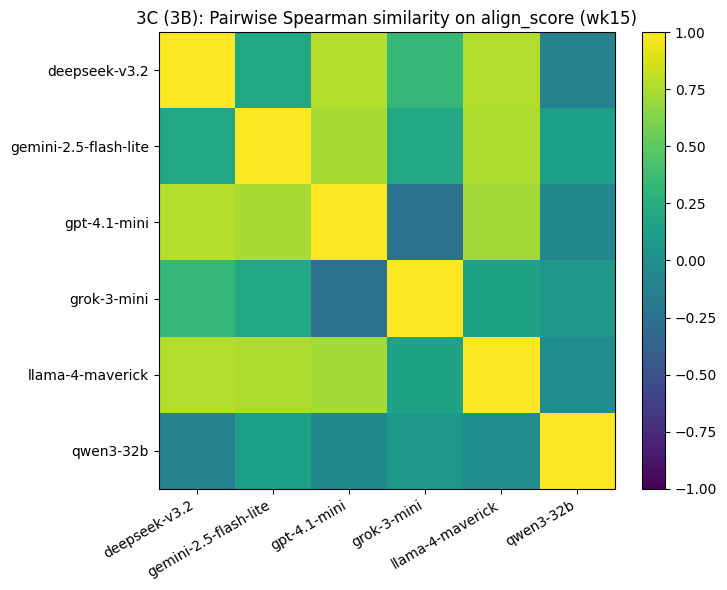

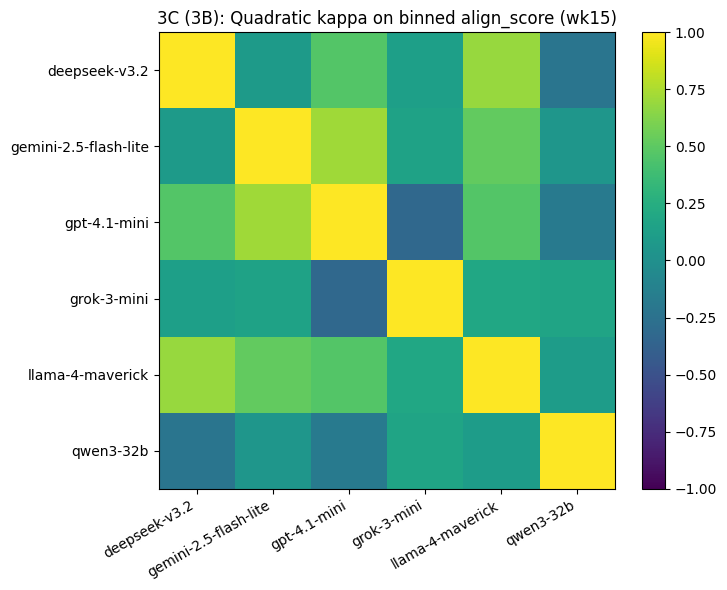

In [9]:
# 3C (3B): per-window consistency
for K in sorted(FILES_3B.keys()):
    print(f"\n===== 3C (3B) Consistency @ wk{K} =====")

    # direction_pred: Cohen's kappa (nominal)
    df_dir_k = df3b_dir_all[df3b_dir_all["wk"] == K].copy()
    if df_dir_k.empty:
        print(f"[WARN] No direction rows for wk{K}")
    else:
        pivot_dir = df_dir_k.pivot_table(
            index=["sample_id", "trait", "opponent"],
            columns="oracle_folder_model",
            values="direction_pred",
            aggfunc="first"
        )
        kappa_dir, n_dir = pairwise_kappa_from_pivot(pivot_dir, weights=None, min_n=2)
        kappa_dir.to_csv(OUT / f"3c_3b_kappa_direction_wk{K}.csv", float_format="%.6f")
        n_dir.to_csv(OUT / f"3c_3b_kappa_direction_wk{K}_n_common.csv")
        plot_heatmap(
            kappa_dir,
            title=f"3C (3B): Pairwise Cohen's kappa on direction_pred (wk{K})",
            out_png=OUT / f"3c_3b_kappa_direction_wk{K}.png",
            vmin=-1, vmax=1
        )

    # align_score: Spearman/Pearson similarity (continuous)
    df_align_k = df3b_align_all[(df3b_align_all["wk"] == K)].dropna(subset=["align_score"]).copy()
    if df_align_k.empty:
        print(f"[WARN] No align rows for wk{K}")
        continue

    pivot_align = df_align_k.pivot_table(
        index=["sample_id"],
        columns="oracle_folder_model",
        values="align_score",
        aggfunc="mean"
    )

    spearman_mat, n_s = pairwise_corr_from_pivot(pivot_align, method="spearman", min_n=3)
    pearson_mat,  n_p = pairwise_corr_from_pivot(pivot_align, method="pearson",  min_n=3)

    spearman_mat.to_csv(OUT / f"3c_3b_align_spearman_wk{K}.csv", float_format="%.6f")
    pearson_mat.to_csv(OUT / f"3c_3b_align_pearson_wk{K}.csv", float_format="%.6f")
    n_s.to_csv(OUT / f"3c_3b_align_pairwise_n_common_wk{K}.csv")

    plot_heatmap(
        spearman_mat,
        title=f"3C (3B): Pairwise Spearman similarity on align_score (wk{K})",
        out_png=OUT / f"3c_3b_align_spearman_wk{K}.png",
        vmin=-1, vmax=1
    )

    # align_score binned: quadratic kappa
    bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.000001]
    align_binned = pivot_align.copy()
    for c in align_binned.columns:
        align_binned[c] = pd.cut(align_binned[c], bins=bins, labels=False, include_lowest=True)

    kappa_align_q, n_bin = pairwise_kappa_from_pivot(align_binned, weights="quadratic", min_n=2)
    kappa_align_q.to_csv(OUT / f"3c_3b_kappa_align_binned_quadratic_wk{K}.csv", float_format="%.6f")
    n_bin.to_csv(OUT / f"3c_3b_kappa_align_binned_quadratic_wk{K}_n_common.csv")

    plot_heatmap(
        kappa_align_q,
        title=f"3C (3B): Quadratic kappa on binned align_score (wk{K})",
        out_png=OUT / f"3c_3b_kappa_align_binned_quadratic_wk{K}.png",
        vmin=-1, vmax=1
    )


C:\Users\eric\AppData\Local\Temp\ipykernel_357736\1775783275.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


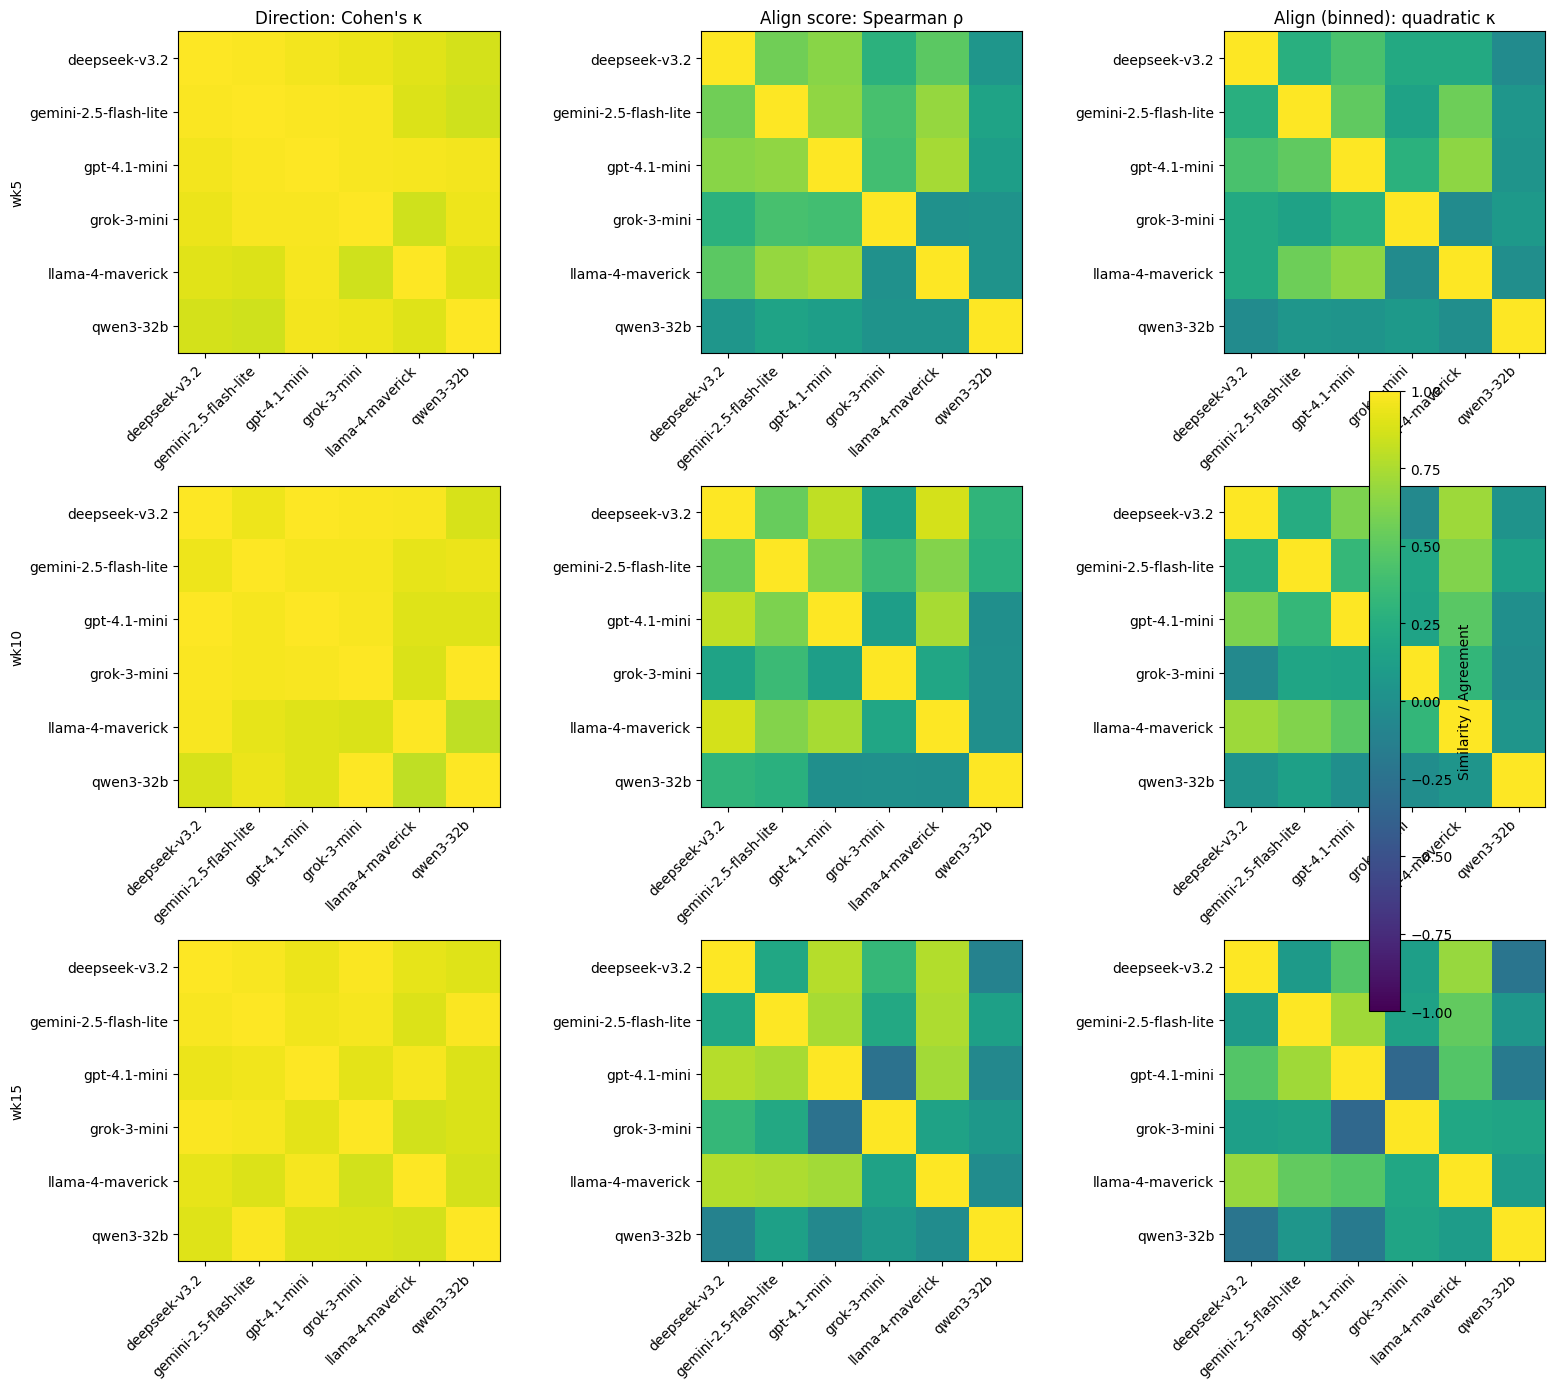

In [10]:
from pathlib import Path
import pandas as pd

OUT = Path("oracle_analysis_out")

def read_mat(fp: Path) -> pd.DataFrame:
    return pd.read_csv(fp, index_col=0)

mats_by_k = {}
for K in [5, 10, 15]:
    mats_by_k[K] = {
        "dir_kappa":      read_mat(OUT / f"3c_3b_kappa_direction_wk{K}.csv"),
        "align_spearman": read_mat(OUT / f"3c_3b_align_spearman_wk{K}.csv"),
        "align_kappa":    read_mat(OUT / f"3c_3b_kappa_align_binned_quadratic_wk{K}.csv"),
    }

def plot_heatmap_grid_3x3(mats_by_k, vmin=-1, vmax=1, figsize=(16, 14), cmap=None, save_path=None, dpi=220):
    Ks = [5, 10, 15]
    keys = ["dir_kappa", "align_spearman", "align_kappa"]
    col_titles = ["Direction: Cohen's κ", "Align score: Spearman ρ", "Align (binned): quadratic κ"]

    labels = list(mats_by_k[Ks[0]][keys[0]].columns)

    fig, axes = plt.subplots(3, 3, figsize=figsize)

    im_for_cbar = None

    for r, K in enumerate(Ks):
        for c, key in enumerate(keys):
            ax = axes[r, c]
            mat = mats_by_k[K][key].loc[labels, labels].values.astype(float)

            im = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap=cmap)
            if im_for_cbar is None:
                im_for_cbar = im

            ax.set_xticks(range(len(labels)))
            ax.set_yticks(range(len(labels)))
            ax.set_xticklabels(labels, rotation=45, ha="right")
            ax.set_yticklabels(labels)

            if r == 0:
                ax.set_title(col_titles[c])
            if c == 0:
                ax.set_ylabel(f"wk{K}")

    cbar = fig.colorbar(im_for_cbar, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
    cbar.set_label("Similarity / Agreement")

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()

plot_heatmap_grid_3x3(
    mats_by_k,
    vmin=-1, vmax=1,
    figsize=(16, 14),
    save_path=OUT / "3c_heatmap_grid_3x3_wk5_10_15.pdf"
)


In [23]:
def plot_heatmap_grid_3x3_with_cbar(mats_by_k, labels, vmin=-1, vmax=1, cmap=None, figsize=(20, 14), save_path=None, dpi=220):
    Ks = [5, 10, 15]
    keys = ["dir_kappa", "align_spearman", "align_kappa"]
    col_titles = ["Direction: Cohen's κ", "Align score: Spearman ρ", "Align (binned): quadratic κ"]

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(nrows=3, ncols=4, width_ratios=[1, 1, 1, 0.06], wspace=0.25, hspace=0.25)

    axes = [[fig.add_subplot(gs[r, c]) for c in range(3)] for r in range(3)]
    cax = fig.add_subplot(gs[:, 3])

    im_for_cbar = None
    for r, K in enumerate(Ks):
        for c, key in enumerate(keys):
            ax = axes[r][c]
            mat = mats_by_k[K][key].loc[labels, labels].values.astype(float)

            im = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap=cmap)
            if im_for_cbar is None:
                im_for_cbar = im

            ax.set_xticks(range(len(labels)))
            ax.set_yticks(range(len(labels)))

            ax.set_xticks(range(len(labels)))
            if r == len(Ks) - 1:
                ax.set_xticklabels(labels, rotation=45, ha="right")
            else:
                ax.set_xticklabels([])
            ax.set_yticks(range(len(labels)))
            if c == 0:
                ax.set_yticklabels(labels)
            else:
                ax.set_yticklabels([])


            if r == 0:
                ax.set_title(col_titles[c])
            if c == 0:
                ax.set_ylabel(f"wk{K}")

    cb = fig.colorbar(im_for_cbar, cax=cax)
    cb.set_label("Similarity / Agreement")

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()


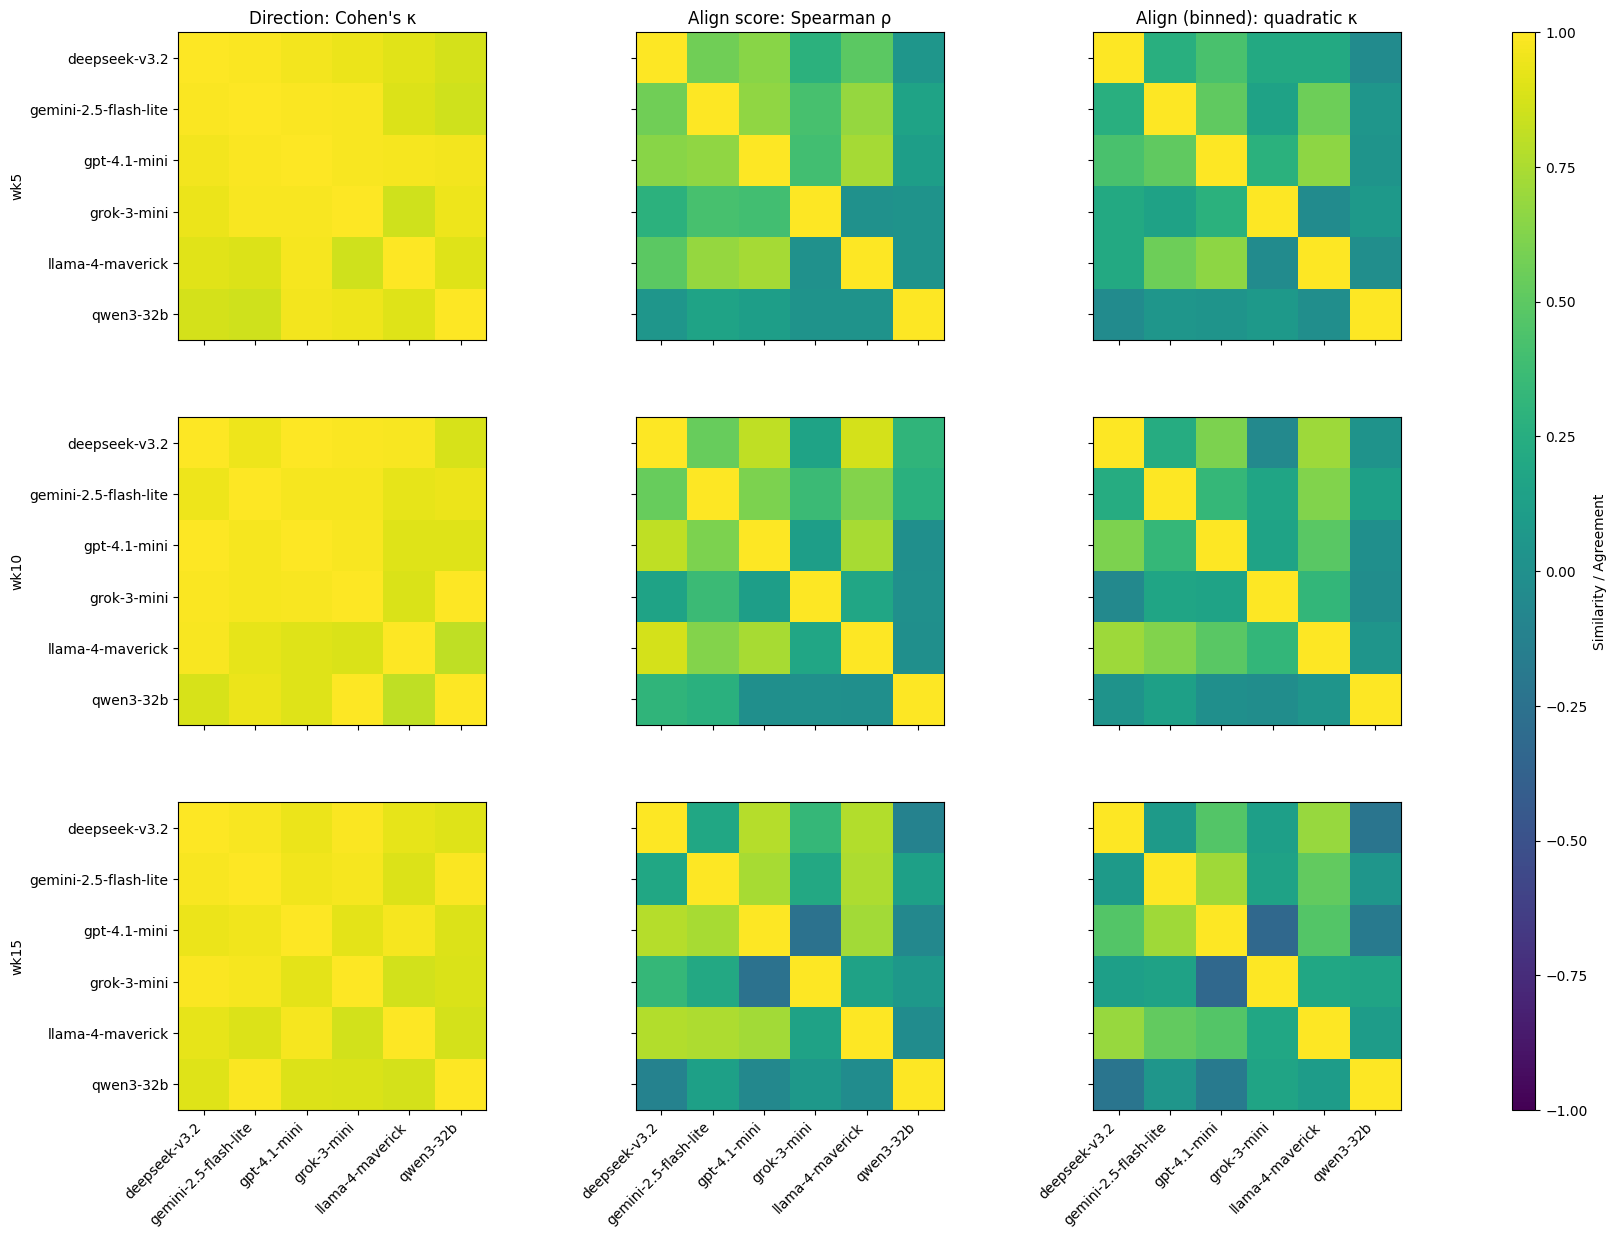

In [25]:
labels = list(mats_by_k[5]["dir_kappa"].columns)
plot_heatmap_grid_3x3_with_cbar(
    mats_by_k,
    labels=labels,
    vmin=-1, vmax=1,
    figsize=(18, 14),
    save_path=OUT / "3c_heatmap_grid_3x3_wk5_10_15.pdf"
)


In [13]:
import numpy as np
import matplotlib.pyplot as plt

def plot_heatmap_grid_3x3_with_numbers(
    mats_by_k,
    labels,
    vmin=-1, vmax=1,
    figsize=(18, 14),
    cmap=None,
    fmt="{:.2f}",
    show_numbers=True,
    upper_triangle_only=True,
    text_size=8,
    save_path=None,
    dpi=220,
):
    Ks = [5, 10, 15]
    keys = ["dir_kappa", "align_spearman", "align_kappa"]
    col_titles = ["Direction: Cohen's κ", "Align score: Spearman ρ", "Align (binned): quadratic κ"]

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(nrows=3, ncols=4, width_ratios=[1, 1, 1, 0.06], wspace=0.25, hspace=0.25)
    axes = [[fig.add_subplot(gs[r, c]) for c in range(3)] for r in range(3)]
    cax = fig.add_subplot(gs[:, 3])

    im_for_cbar = None

    for r, K in enumerate(Ks):
        for c, key in enumerate(keys):
            ax = axes[r][c]
            df = mats_by_k[K][key].loc[labels, labels]
            data = df.values.astype(float)

            im = ax.imshow(data, vmin=vmin, vmax=vmax, cmap=cmap)
            if im_for_cbar is None:
                im_for_cbar = im

            ax.set_xticks(range(len(labels)))
            ax.set_yticks(range(len(labels)))
            ax.set_xticklabels(labels, rotation=45, ha="right")
            ax.set_yticklabels(labels)

            if r == 0:
                ax.set_title(col_titles[c])
            if c == 0:
                ax.set_ylabel(f"wk{K}")

            # ---- draw numbers ----
            if show_numbers:
                n = data.shape[0]
                for i in range(n):
                    for j in range(n):
                        if upper_triangle_only and j < i:
                            continue
                        val = data[i, j]
                        if np.isnan(val):
                            s = "nan"
                        else:
                            s = fmt.format(val)
                        ax.text(j, i, s, ha="center", va="center", fontsize=text_size)

    cb = fig.colorbar(im_for_cbar, cax=cax)
    cb.set_label("Similarity / Agreement")

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()


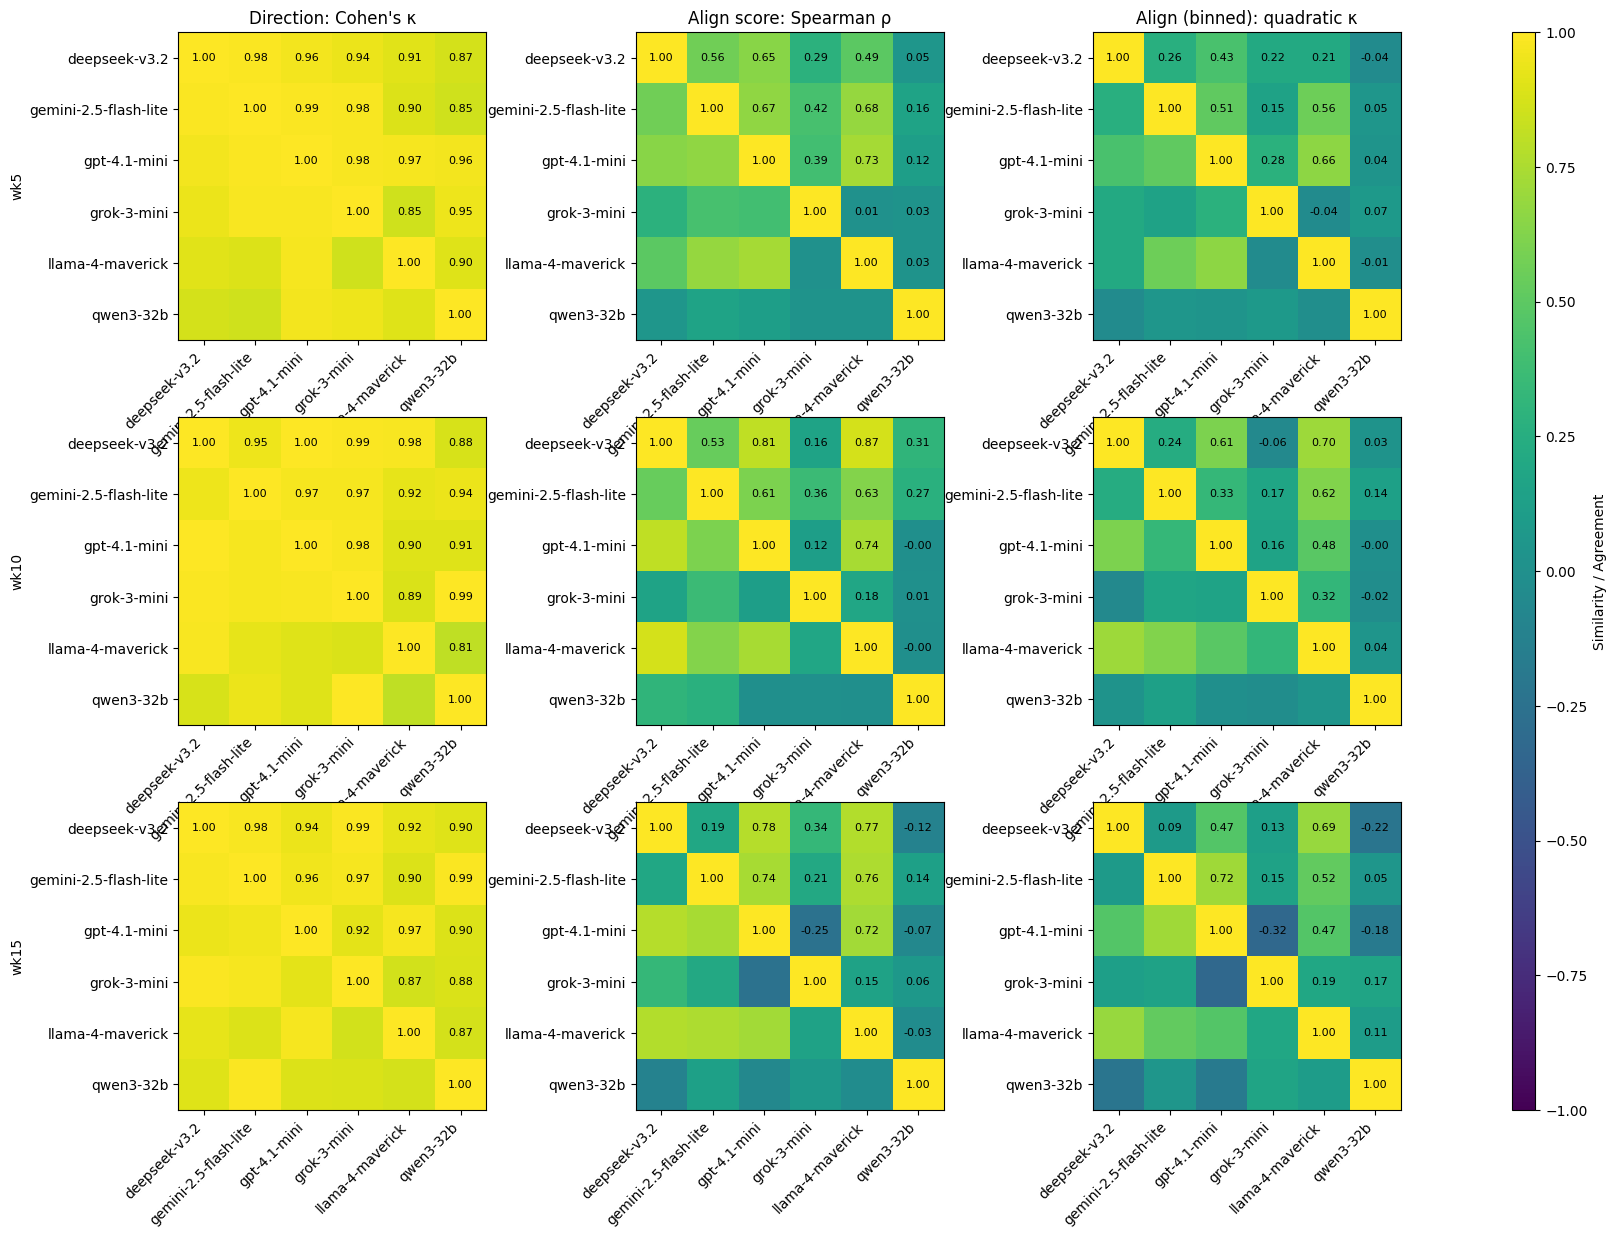

In [14]:
labels = list(mats_by_k[5]["dir_kappa"].columns)
plot_heatmap_grid_3x3_with_numbers(
    mats_by_k,
    labels=labels,
    vmin=-1, vmax=1,
    fmt="{:.2f}",
    text_size=8,
    upper_triangle_only=True,
    save_path=OUT / "3c_heatmap_grid_3x3_numbers.png"
)


In [16]:
from pathlib import Path

def export_heatmap_matrices(mats_by_k, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    name_map = {
        "dir_kappa": "direction_kappa",
        "align_spearman": "align_spearman",
        "align_kappa": "align_binned_quadratic_kappa",
    }
    for K, d in mats_by_k.items():
        for key, df in d.items():
            fp = out_dir / f"wk{K}_{name_map.get(key, key)}.csv"
            df.to_csv(fp, float_format="%.6f")
            print("saved:", fp)

export_heatmap_matrices(mats_by_k, OUT / "matrices_export")


saved: oracle_analysis_out\matrices_export\wk5_direction_kappa.csv
saved: oracle_analysis_out\matrices_export\wk5_align_spearman.csv
saved: oracle_analysis_out\matrices_export\wk5_align_binned_quadratic_kappa.csv
saved: oracle_analysis_out\matrices_export\wk10_direction_kappa.csv
saved: oracle_analysis_out\matrices_export\wk10_align_spearman.csv
saved: oracle_analysis_out\matrices_export\wk10_align_binned_quadratic_kappa.csv
saved: oracle_analysis_out\matrices_export\wk15_direction_kappa.csv
saved: oracle_analysis_out\matrices_export\wk15_align_spearman.csv
saved: oracle_analysis_out\matrices_export\wk15_align_binned_quadratic_kappa.csv
